# Dynamic Topic Modeling: Health Misinformation Over Time

**Goal**: Track how health-related misinformation topics evolve across time using LDA and BERTopic, comparing topic evolution across 2-year windows.

**Temporal data**: Uses real tweet timestamps from `Truth_Seeker_Model_Dataset_With_TimeStamps.xlsx` ( `created_at`： 2008–2022). 

---
## 0. Setup & Imports

In [44]:
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import defaultdict, Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from scipy.spatial.distance import jensenshannon

# Visualization
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# Download NLTK data
for resource in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
RANDOM_STATE = 42

# Reproducibility controls for stochastic topic models.
import random
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Data Loading & Merging

In [45]:
import os
DATA_DIR = "data/"
PLOT_DIR = "output/"

# Load feature dataset (engineered NLP features + text)
features_df = pd.read_csv(DATA_DIR + "Features_For_Traditional_ML_Techniques.csv",
                          index_col=0)

# Load base metadata dataset
meta_df = pd.read_csv(DATA_DIR + "Truth_Seeker_Model_Dataset.csv",
                      index_col=0)

# ── Load timestamped dataset ─────────────────────────────────────────────────
# File is an Excel (.xlsx); place it in data/ or update the path below.
TIMESTAMPS_PATH = os.path.expanduser(
    "~/Downloads/TruthSeeker2023/Truth_Seeker_Model_Dataset_With_TimeStamps 1.xlsx"
)
ALT_TIMESTAMPS_PATH = DATA_DIR + "Truth_Seeker_Model_Dataset_With_TimeStamps.xlsx"

if os.path.exists(ALT_TIMESTAMPS_PATH):
    ts_df = pd.read_excel(ALT_TIMESTAMPS_PATH, index_col=0)
    print(f"✓ Loaded timestamps from {ALT_TIMESTAMPS_PATH}")
elif os.path.exists(TIMESTAMPS_PATH):
    ts_df = pd.read_excel(TIMESTAMPS_PATH, index_col=0)
    print(f"✓ Loaded timestamps from {TIMESTAMPS_PATH}")
    print("  Tip: copy this file to data/ for cleaner project layout.")
else:
    ts_df = None
    print("⚠ Timestamped file not found — Section 3 will use year-proxy fallback.")

# Parse the timestamp column
if ts_df is not None:
    ts_df['timestamp'] = pd.to_datetime(
        ts_df['timestamp'],
        format='%a %b %d %H:%M:%S +0000 %Y',
        utc=True,
        errors='coerce'
    )
    print(f"  Date range: {ts_df['timestamp'].min().date()} → {ts_df['timestamp'].max().date()}")
    print(f"  Year distribution:\n{ts_df['timestamp'].dt.year.value_counts().sort_index().to_string()}")

#  Merge all sources 
df = features_df.copy()
df['manual_keywords'] = meta_df['manual_keywords'].values
df['author']          = meta_df['author'].values
df['label_5']         = meta_df['5_label_majority_answer'].values

if ts_df is not None:
    # Align timestamps by the original row index, not by position. The timestamped
    # file has a few extra rows, so positional assignment can attach COVID-era
    # tweets to pre-2020 timestamps.
    ts_aligned = ts_df.reindex(df.index)
    statement_match = (df['statement'].astype(str) == ts_aligned['statement'].astype(str)).mean()
    print(f"  Timestamp alignment statement match: {statement_match:.2%}")
    df['timestamp'] = ts_aligned['timestamp']

print(f"\nMerged shape: {df.shape}")
print(f"Unique statements: {df['statement'].nunique()}")
print(f"Label distribution:\n{df['majority_target'].value_counts()}")
df.head(5)

✓ Loaded timestamps from data/Truth_Seeker_Model_Dataset_With_TimeStamps.xlsx
  Date range: 2008-02-05 → 2022-03-01
  Year distribution:
timestamp
2008.0       13
2009.0      159
2010.0      277
2011.0      978
2012.0     2365
2013.0     3347
2014.0     1782
2015.0     3065
2016.0     3348
2017.0     3493
2018.0     7639
2019.0     9708
2020.0    34352
2021.0    55640
2022.0     8028
  Timestamp alignment statement match: 100.00%

Merged shape: (134198, 67)
Unique statements: 1058
Label distribution:
majority_target
True     68985
False    65213
Name: count, dtype: int64


,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,following,...,questions,ampersand,capitals,digits,long_word_freq,short_word_freq,manual_keywords,author,label_5,timestamp
0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,0.0,...,1,0,33,3,5,19,"Americans, eviction moratorium",D.L. Davis,Mostly Agree,2021-09-09 23:58:53+00:00
1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,0.0,...,0,0,14,0,2,34,"Americans, eviction moratorium",D.L. Davis,NO MAJORITY,2021-08-30 18:58:09+00:00
2,True,End of eviction moratorium means millions of A...,1.0,THE SUPREME COURT is siding with super rich pr...,9.0,84.0,219.0,1184.0,0.0,0.0,...,0,0,3,0,4,10,"Americans, eviction moratorium",D.L. Davis,Agree,2021-08-27 09:53:44+00:00
3,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders\n\nBroken campaign promi...,4262.0,3619.0,34945.0,16423.0,44.0,0.0,...,0,1,6,8,1,30,"Americans, eviction moratorium",D.L. Davis,Mostly Agree,2021-10-05 20:37:14+00:00
4,True,End of eviction moratorium means millions of A...,1.0,@OhComfy I agree. The confluence of events rig...,70.0,166.0,15282.0,2194.0,0.0,0.0,...,1,0,11,3,2,19,"Americans, eviction moratorium",D.L. Davis,Agree,2021-08-27 10:58:24+00:00


## 2. Data Cleaning & Health Filtering

In [46]:
# Drop nulls in core columns
df = df.dropna(subset=['statement', 'tweet'])

# Ensure binary label is clean
df['label'] = df['BinaryNumTarget'].fillna(0).astype(int)  # 1=True/Credible, 0=False/Misinformation

print(f"After null drop: {df.shape}")
print(f"Label counts: {df['label'].value_counts().to_dict()}")

After null drop: (134198, 68)
Label counts: {1: 68930, 0: 65268}


### Health-topic filtering

Applied to `statement` (the claim itself) to avoid false positives from tweet context.

In [47]:
HEALTH_TERMS = [
    # Vaccines & immunization
    r'vaccin', r'immuniz', r'ivermectin', r'hydroxychloroquine', r'booster',
    r'pfizer', r'moderna', r'astrazeneca', r'johnson',
    # COVID / pandemic
    r'covid', r'coronavirus', r'pandemic', r'quarantine', r'lockdown',
    r'mask', r'ppe', r'social.distanc',
    # General health
    r'\bhealth\b', r'\bdisease\b', r'\bvirus\b', r'\bflu\b',
    r'\bcancer\b', r'\bdrug\b', r'hospital', r'\bCDC\b', r'\bFDA\b',
    r'\bWHO\b', r'\bFauci\b', r'\bpublic health\b', r'convalescent',
    r'\bplasma\b', r'asymptomatic', r'herd immunity', r'natural immunity',
]

pattern = '|'.join(HEALTH_TERMS)
health_mask = df['statement'].str.contains(pattern, case=False, na=False, regex=True)
health_df = df[health_mask].copy()

print(f"Health-related rows: {len(health_df):,} / {len(df):,} ({100*len(health_df)/len(df):.1f}%)")
print(f"Unique health statements: {health_df['statement'].nunique()}")
print(f"\nTop health topics (manual_keywords):")
health_df['manual_keywords'].value_counts().head(20)

Health-related rows: 33,254 / 134,198 (24.8%)
Unique health statements: 216

Top health topics (manual_keywords):


manual_keywords
George Floyd, died, drug overdose                 498
racism, public health crisis                      498
Biden,tax,401k                                    497
Aluminum,vaccine,brain                            497
cure, hydroxychloroquine                          497
Herd immunity, reached                            497
asymptomatic,transmission,covid-19                496
pelosi, made millions, insider trading            496
cases are going up, because, testing, going up    496
hydroxychloroquine, CNN                           495
cigarettes,FDA approved                           495
convalescent plasma therapy                       495
1986,vaccine,children                             495
I am Legend,zombie,vaccine                        494
HIPAA  vaccination status                         494
natural immunity,covid,vaccine                    494
Republicans, cut, health insurance                493
voter fraud last november                         493
Herman Cain,

In [48]:
print("Health subset — label distribution:")
print(health_df['label'].value_counts())
print(f"\nMisinformation rate: {(health_df['label']==0).mean()*100:.1f}%")

Health subset — label distribution:
label
0    24530
1     8724
Name: count, dtype: int64

Misinformation rate: 73.8%


## 3. Temporal Chunking

In [49]:
def extract_year_proxy(text, min_year=2015, max_year=2023):
    """Fallback: most recent plausible year found in tweet text."""
    years = re.findall(r'\b(20[1-2]\d)\b', str(text))
    years = [int(y) for y in years if min_year <= int(y) <= max_year]
    return max(years) if years else np.nan


if 'timestamp' in health_df.columns and health_df['timestamp'].notna().sum() > 0:
    health_df['tweet_year'] = pd.to_datetime(health_df['timestamp'], utc=True, errors='coerce').dt.year
    print(f"Using real timestamps — {health_df['tweet_year'].notna().sum():,} valid")
else:
    health_df['tweet_year'] = health_df['tweet'].apply(extract_year_proxy)
    print(f"Using year-proxy fallback — {health_df['tweet_year'].notna().sum():,} valid")

print(health_df['tweet_year'].value_counts().sort_index())

Using real timestamps — 33,254 valid
tweet_year
2008        4
2009       12
2010       26
2011       96
2012      186
2013      279
2014       61
2015      266
2016      161
2017      227
2018      595
2019     1294
2020     8016
2021    17925
2022     4106
Name: count, dtype: int64


### 3b. Assign 2-year temporal windows and filter for fake news only

majority_target dtype: bool
Sample values: [ True False]

Fake news documents per 2-year window:
time_window
2015-2016       22
2017-2018      149
2019-2020     5925
2021-2022    17573
Name: count, dtype: int64

Total fake news docs: 23,669


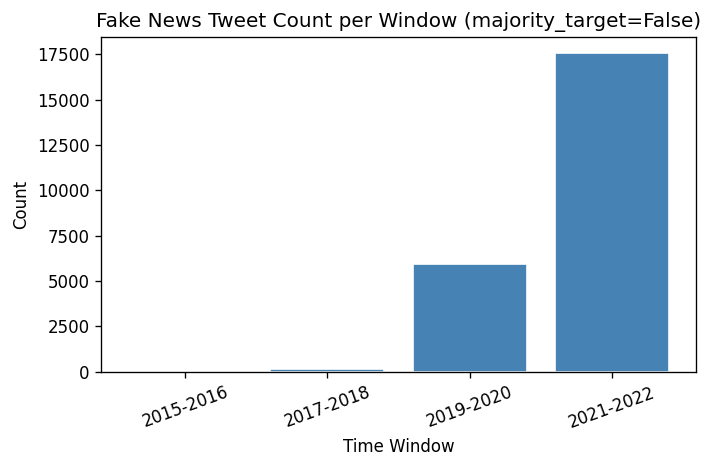

In [50]:
WINDOW_BINS   = [2014, 2016, 2018, 2020, 2022]
WINDOW_LABELS = ['2015-2016', '2017-2018', '2019-2020', '2021-2022']

health_df['time_window'] = pd.cut(
    health_df['tweet_year'],
    bins=WINDOW_BINS,
    labels=WINDOW_LABELS,
    right=True
)

temporal_df = health_df.dropna(subset=['time_window']).copy()

temporal_df = temporal_df[temporal_df['majority_target'].astype(str).str.strip() == 'False'].copy()

temporal_df['time_window'] = temporal_df['time_window'].astype(str)

print(f"majority_target dtype: {health_df['majority_target'].dtype}")
print(f"Sample values: {health_df['majority_target'].unique()[:4]}")
print(f"\nFake news documents per 2-year window:")
print(temporal_df['time_window'].value_counts().sort_index())
print(f"\nTotal fake news docs: {len(temporal_df):,}")

fig, ax = plt.subplots(figsize=(6, 4))
window_counts = temporal_df['time_window'].value_counts().sort_index()
ax.bar(window_counts.index, window_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Fake News Tweet Count per Window (majority_target=False)')
ax.set_xlabel('Time Window')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_fake_news_counts.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Preprocessing

 lowercase → strip URLs/@mentions → remove punctuation → tokenize → stopwords → lemmatize → keep alpha tokens ≥ 3 chars.

In [51]:
lemmatizer = WordNetLemmatizer()
base_stops = set(stopwords.words('english'))

DOMAIN_STOPS = {
    'said', 'say', 'says', 'people', 'would', 'could', 'also', 'one', 'two',
    'get', 'got', 'go', 'going', 'like', 'make', 'know', 'think', 'time',
    'year', 'new', 'many', 'even', 'way', 'need', 'take', 'come', 'see',
    'well', 'good', 'right', 'day', 'fact', 'claim', 'true', 'false',
    'report', 'show', 'find', 'use', 'amp',
    'https', 'http', 'twitter', 'tweet', 'rt', 'via', 'video', 'watch',
    'read', 'article', 'link', 'share', 'post', 'news'
}

ALL_STOPS = base_stops | DOMAIN_STOPS

def clean_text(text):
    """Full preprocessing pipeline: returns a list of clean tokens."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok.isalpha()
        and len(tok) >= 3
        and tok not in ALL_STOPS
    ]
    return tokens


print("Preprocessing health documents...")
temporal_df['tokens'] = temporal_df['tweet'].apply(clean_text)
temporal_df['clean_text'] = temporal_df['tokens'].apply(lambda toks: ' '.join(toks))

sample_row = temporal_df.iloc[0]
print(f"\nOriginal tweet: {sample_row['tweet'][:80]}...")
print(f"Clean tokens (first 15): {sample_row['tokens'][:15]}")
print(f"\nTotal documents in temporal corpus: {len(temporal_df):,}")

Preprocessing health documents...

Original tweet: @Riguy_453 @PaulSorrentino3 @POTUS Trump didn't attempt to mandate mask!! Biden ...
Clean tokens (first 15): ['trump', 'attempt', 'mandate', 'mask', 'biden', 'wanted', 'vaccine', 'republican', 'american', 'comply', 'supreme', 'court', 'knocked', 'eviction', 'moratorium']

Total documents in temporal corpus: 23,669


In [52]:
## Top terms per window
print("Top 20 terms per time window (raw frequency):")
print("=" * 60)
for win in WINDOW_LABELS:
    win_tokens = temporal_df[temporal_df['time_window'] == win]['tokens']
    flat_tokens = [tok for toks in win_tokens for tok in toks]
    top = Counter(flat_tokens).most_common(20)
    terms = [f"{w}({n})" for w, n in top]
    print(f"\n[{win}] — {len(win_tokens):,} docs")
    print("  " + ', '.join(terms))

Top 20 terms per time window (raw frequency):

[2015-2016] — 22 docs
  body(6), mike(5), huckabee(5), diabetes(5), law(4), camera(4), child(3), release(3), public(3), cure(3), million(2), health(2), let(2), dallas(2), passed(2), saying(2), footage(2), eddie(2), glaude(2), chair(2)

[2017-2018] — 149 docs
  vaccine(65), child(51), aluminum(42), brain(36), gun(32), trump(27), separate(20), positive(19), death(19), health(18), infant(18), second(16), woman(16), amendment(16), organization(15), terrorist(15), antifa(14), syndrome(13), type(13), scream(13)

[2019-2020] — 5,925 docs
  covid(2227), vaccine(2023), trump(1445), child(968), death(816), age(808), coronavirus(717), died(708), rate(674), virus(591), cdc(587), mask(581), case(571), doctor(561), test(528), cancer(521), almost(515), positive(490), china(471), without(467)

[2021-2022] — 17,573 docs
  vaccine(8784), covid(5897), mask(2544), vaccinated(2467), immunity(1946), death(1643), biden(1573), pfizer(1502), fauci(1477), approved(

## 5. LDA Topic Modeling

Single LDA (K=6 topics) trained on **all** fake-news documents combined. Per-window topic prevalence is then computed by applying the global model to each window's documents, so topic identities are consistent across windows.

In [53]:
N_TOPICS = 6
N_TOP_WORDS = 10
MAX_FEATURES = 3000  # vocabulary cap

# ── Train ONE global LDA on all fake-news documents ──────────────────────────
all_fake_docs = temporal_df['clean_text'].tolist()

cv_global = CountVectorizer(
    max_features=MAX_FEATURES,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2)
)
dtm_global = cv_global.fit_transform(all_fake_docs)

lda_global = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='batch',  # deterministic full-batch updates for reproducibility
    random_state=RANDOM_STATE,
    n_jobs=1                  # avoid non-deterministic parallel update ordering
)
doc_topic_global = lda_global.fit_transform(dtm_global)

vocab = cv_global.get_feature_names_out()
top_words_global = []
for topic_vec in lda_global.components_:
    top_idx = topic_vec.argsort()[:-N_TOP_WORDS - 1:-1]
    top_words_global.append([vocab[i] for i in top_idx])

perp = lda_global.perplexity(dtm_global)
print(f"Global LDA | All fake-news docs: {len(all_fake_docs):,} | Perplexity: {perp:.1f}")

# ── Slice per-window doc-topic matrices (model/vocabulary are shared) ─────────
lda_results = {}
temporal_reset = temporal_df.reset_index(drop=True)

for win in WINDOW_LABELS:
    win_idx = temporal_reset.index[temporal_reset['time_window'] == win].tolist()
    if len(win_idx) < 50:
        print(f"[{win}] Too few docs ({len(win_idx)}), skipping.")
        continue
    lda_results[win] = {
        'model':            lda_global,
        'vectorizer':       cv_global,
        'top_words':        top_words_global,
        'doc_topic_matrix': doc_topic_global[win_idx],
        'n_docs':           len(win_idx),
    }
    print(f"[{win}] Docs: {len(win_idx):,}")

print("\nLDA fitting complete.")

Global LDA | All fake-news docs: 23,669 | Perplexity: 949.9
[2015-2016] Too few docs (22), skipping.
[2017-2018] Docs: 149
[2019-2020] Docs: 5,925
[2021-2022] Docs: 17,573

LDA fitting complete.


### 5a. Top words per topic per window

In [54]:
print("Global LDA — Top 10 terms per topic (trained on all fake-news documents):\n")
print("=" * 60)
for t_idx, words in enumerate(top_words_global):
    print(f"  Topic {t_idx+1}: {', '.join(words)}")

print("\n\nTopic prevalence per time window")
print("(% of docs whose dominant topic is each topic)\n")

header = f"{'Topic':<10}" + "".join(f"{w:>14}" for w in WINDOW_LABELS if w in lda_results)
print(header)
print("-" * len(header))

windows_with_data = [w for w in WINDOW_LABELS if w in lda_results]
dominant_per_window = {}
for win in windows_with_data:
    dtm = lda_results[win]['doc_topic_matrix']
    dominant_per_window[win] = np.argmax(dtm, axis=1)  # 0-based topic index

for t_idx in range(N_TOPICS):
    row = f"Topic {t_idx+1:<4}"
    for win in windows_with_data:
        dom = dominant_per_window[win]
        pct = (dom == t_idx).sum() / len(dom) * 100
        row += f"{pct:>13.1f}%"
    print(row)

print("-" * len(header))
totals = f"{'N docs':<10}"
for win in windows_with_data:
    totals += f"{lda_results[win]['n_docs']:>14,}"
print(totals)

Global LDA — Top 10 terms per topic (trained on all fake-news documents):

  Topic 1: mask, vaccinated, trump, fauci, hydroxychloroquine, wearing, covid, wear, science, believe
  Topic 2: vaccine, approved, fda, pfizer, mrna, mandate, fda approved, china, therapy, gene
  Topic 3: biden, million, pelosi, george, floyd, drug, george floyd, made, tax, died
  Topic 4: covid, vaccine, test, border, cancer, positive, brain, died, open, cause
  Topic 5: vaccine, covid, death, covid vaccine, case, doctor, vaccination, number, prevent, testing
  Topic 6: covid, immunity, vaccine, child, rate, variant, herd, herd immunity, age, virus


Topic prevalence per time window
(% of docs whose dominant topic is each topic)

Topic          2017-2018     2019-2020     2021-2022
----------------------------------------------------
Topic 1            14.1%         16.1%         20.9%
Topic 2             3.4%         15.2%         18.8%
Topic 3            22.8%          7.3%         11.9%
Topic 4            2

### 5b. Mean topic weight distribution per window

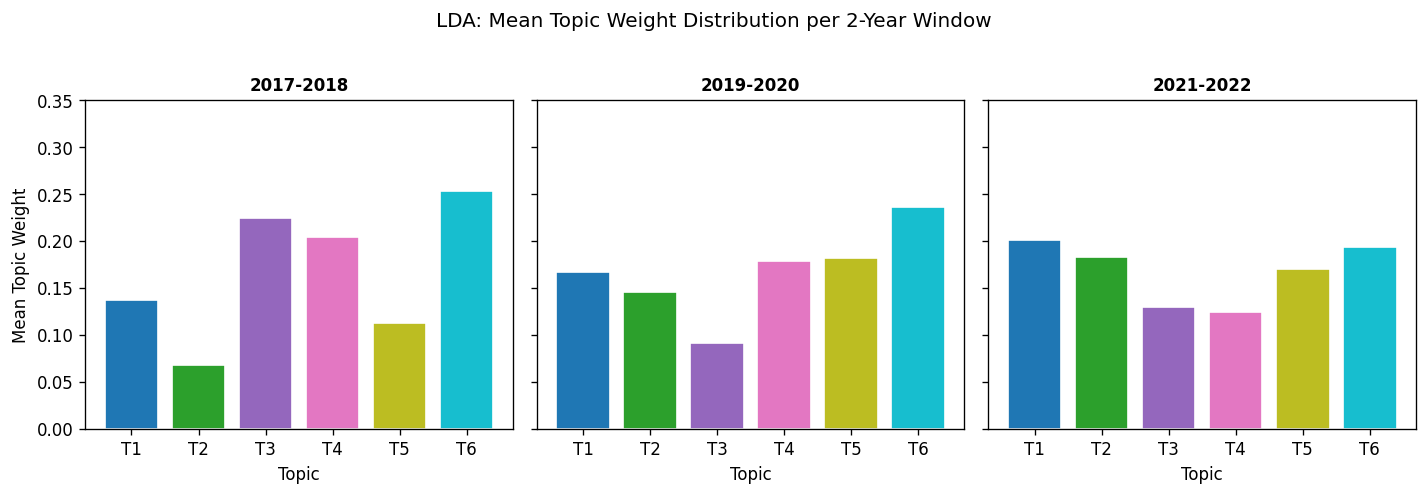

In [55]:
windows_available = [w for w in WINDOW_LABELS if w in lda_results]
n_win = len(windows_available)

fig, axes = plt.subplots(1, n_win, figsize=(4 * n_win, 4), sharey=True)
if n_win == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, N_TOPICS))

for ax, win in zip(axes, windows_available):
    mean_weights = lda_results[win]['doc_topic_matrix'].mean(axis=0)
    topic_labels = [f"T{i+1}" for i in range(N_TOPICS)]
    bars = ax.bar(topic_labels, mean_weights, color=colors, edgecolor='white')
    ax.set_title(win, fontsize=10, fontweight='bold')
    ax.set_xlabel('Topic')
    ax.set_ylim(0, 0.35)

axes[0].set_ylabel('Mean Topic Weight')
plt.suptitle('LDA: Mean Topic Weight Distribution per 2-Year Window', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_lda_topic_weights.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. BERTopic Dynamic Topic Modeling (DTM)

BERTopic uses transformer embeddings + UMAP + HDBSCAN to discover topics, then `topics_over_time` tracks how each topic's frequency evolves across the 4 time windows — without fitting a separate model per period, so topic identities are consistent across windows.

In [56]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

docs_bt       = temporal_df['clean_text'].tolist()
timestamps_bt = temporal_df['time_window'].tolist()   # 4 pre-defined windows as timestamps

umap_model       = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                        metric='cosine', random_state=RANDOM_STATE)
hdbscan_model    = HDBSCAN(min_cluster_size=50, metric='euclidean',
                            cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2))

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics=N_TOPICS,
    verbose=True
)

bt_topics, _ = topic_model.fit_transform(docs_bt)

n_real_topics = len([t for t in set(bt_topics) if t != -1])
print(f"Topics found (excl. outliers): {n_real_topics}")
print(f"Outlier docs (-1):             {sum(t == -1 for t in bt_topics):,}")
topic_model.get_topic_info()

2026-05-30 20:22:26,986 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 740/740 [00:11<00:00, 64.82it/s] 
2026-05-30 20:22:41,288 - BERTopic - Embedding - Completed ✓
2026-05-30 20:22:41,289 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-30 20:22:51,107 - BERTopic - Dimensionality - Completed ✓
2026-05-30 20:22:51,108 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-30 20:22:53,180 - BERTopic - Cluster - Completed ✓
2026-05-30 20:22:53,181 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-30 20:22:53,439 - BERTopic - Representation - Completed ✓
2026-05-30 20:22:53,439 - BERTopic - Topic reduction - Reducing number of topics
2026-05-30 20:22:53,449 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-30 20:22:53,672 - BERTopic - Representation - Completed ✓
2026-05-30 20:22:53,673 - BERTopic - Topic reduction - R

Topics found (excl. outliers): 5
Outlier docs (-1):             2,994


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2994,-1_vaccine_covid_vaccinated_risk,"[vaccine, covid, vaccinated, risk, case, dont,...",[real science dont vaccine risk covid vaccine ...
1,0,16044,0_vaccine_covid_death_vaccinated,"[vaccine, covid, death, vaccinated, child, vir...",[neither gene therapy trad vaccine unlike conv...
2,1,2933,1_biden_border_open_voter,"[biden, border, open, voter, tax, million, fra...",[biden admin discussing mandating covid vaccin...
3,2,1207,2_george_judge_criminal_covid,"[george, judge, criminal, covid, record, polic...","[george floyd died drug overdose, george floyd..."
4,3,347,3_antifa_terrorist_organization_trump,"[antifa, terrorist, organization, trump, fasci...","[antifa trump labeled terrorist organization, ..."
5,4,144,4_charge_dropped_stole_gun,"[charge, dropped, stole, gun, defense, self, m...","[charge dropped kyle rittenhouse, kyle rittenh..."


### 6a. Top terms per BERTopic topic

In [57]:
print("BERTopic — Top 10 terms per topic:")
print("=" * 60)
for topic_id, words in sorted(topic_model.get_topics().items()):
    if topic_id == -1:
        continue
    terms = ', '.join([w for w, _ in words[:10]])
    count = sum(t == topic_id for t in bt_topics)
    print(f"  Topic {topic_id + 1:2d} ({count:,} docs): {terms}")

BERTopic — Top 10 terms per topic:
  Topic  1 (16,044 docs): vaccine, covid, death, vaccinated, child, virus, case, approved, rate, age
  Topic  2 (2,933 docs): biden, border, open, voter, tax, million, fraud, voter fraud, american, capitol
  Topic  3 (1,207 docs): george, judge, criminal, covid, record, police, cop, woman, death, rally
  Topic  4 (347 docs): antifa, terrorist, organization, trump, fascist, group, domestic, anti, white, violence
  Topic  5 (144 docs): charge, dropped, stole, gun, defense, self, million, black, guilty, weapon


### 6b. Dynamic topic evolution over time

`topics_over_time` computes, for each topic, how frequently it appears in each time window using the same model fitted on all data — topic identities are consistent across windows.

In [58]:

# BERTopic requires numeric or parseable datetime timestamps.
# Map window labels to their start year (int) so pd.to_datetime is not invoked,
# then remap the result back to the original label strings for all downstream cells.
WINDOW_TO_YEAR = {
    '2015-2016': 2015,
    '2017-2018': 2017,
    '2019-2020': 2019,
    '2021-2022': 2021,
}
YEAR_TO_WINDOW = {v: k for k, v in WINDOW_TO_YEAR.items()}

timestamps_int = temporal_df['time_window'].map(WINDOW_TO_YEAR).tolist()

# Verify alignment: every doc must have a mapped timestamp (no NaN)
n_unmapped = sum(pd.isna(t) for t in timestamps_int)
print(f"Docs with unmapped timestamp: {n_unmapped} (should be 0)")
print(f"Timestamp value counts: {pd.Series(timestamps_int).value_counts().sort_index().to_dict()}")

# global_tuning=True would average each window's c-TF-IDF with the GLOBAL model,
# which is overwhelmingly vaccine/COVID-era (2021-22) and bleeds those terms into
# the sparse 2015-2016 window. Disable both tuning flags for window-faithful words.
topics_over_time = topic_model.topics_over_time(
    docs_bt,
    timestamps_int,
    global_tuning=False,
    evolution_tuning=False,
)

bt_valid = topics_over_time[topics_over_time['Topic'] != -1].copy()
# Shift topic IDs to 1-based for display; model internals remain 0-based
bt_valid['Topic'] = bt_valid['Topic'] + 1
# Remap integer years back to window-label strings so downstream cells are unaffected
bt_valid['Timestamp'] = bt_valid['Timestamp'].map(YEAR_TO_WINDOW)

# Dominant topic per window (highest frequency) — values are now 1-based
bt_dom_per_window = (
    bt_valid.loc[bt_valid.groupby('Timestamp')['Frequency'].idxmax()]
    .set_index('Timestamp')['Topic']
    .to_dict()
)

print("\nTopics over time (sample):")
print(bt_valid.head(12).to_string(index=False))
print(f"\nDominant topic per window: {bt_dom_per_window}")


Docs with unmapped timestamp: 0 (should be 0)
Timestamp value counts: {2015: 22, 2017: 149, 2019: 5925, 2021: 17573}


4it [00:00, 23.72it/s]


Topics over time (sample):
 Topic                                                   Words  Frequency Timestamp
     1                   body, law, public, passed, healthcare         16 2015-2016
     2                        current, non, pay, record, trump          2 2015-2016
     1                 brain, child, vaccine, death, insurance         87 2017-2018
     2                    white, job, majority, black, america          7 2017-2018
     3                       supreme, sex, door, drop, dropped          3 2017-2018
     4 terrorist, antifa, organization, trump, trump supporter         12 2017-2018
     1                        covid, age, child, vaccine, rate       4082 2019-2020
     2                 voter, fraud, voter fraud, biden, trump        408 2019-2020
     3                       judge, george, covid, rally, year        527 2019-2020
     4         antifa, terrorist, organization, trump, fascist        311 2019-2020
     5                charge, dropped, stole, mi

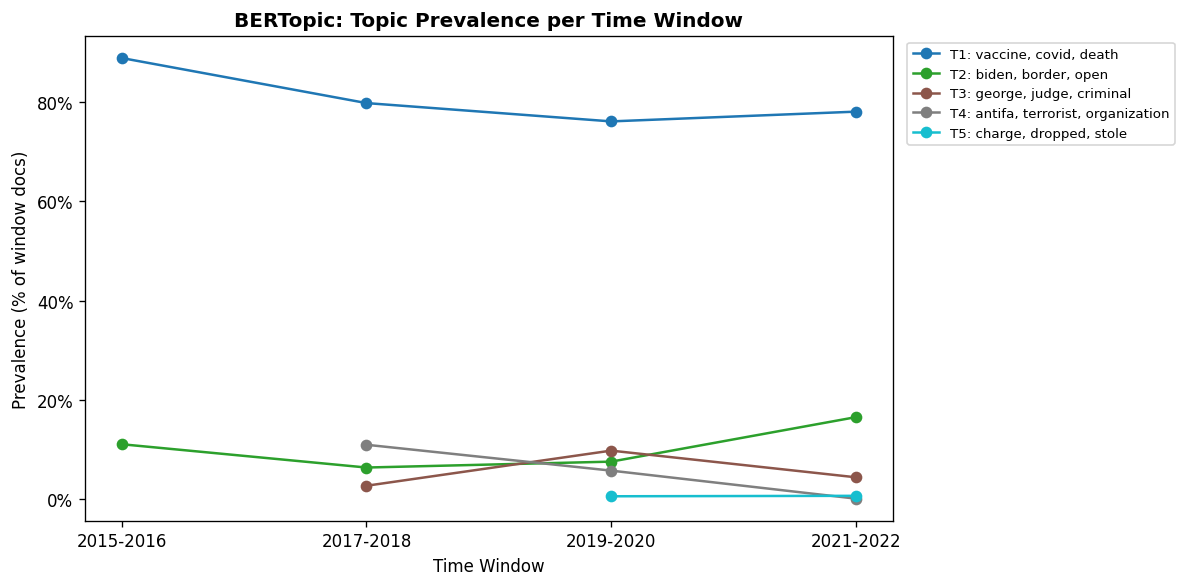

In [59]:
# ── Single static plot: topic prevalence (%) per window ───────────────────────
win_order = {w: i for i, w in enumerate(WINDOW_LABELS)}
min_tid   = int(bt_valid['Topic'].min())
topic_ids_sorted = sorted(bt_valid['Topic'].unique())
colors_bt = plt.cm.tab10(np.linspace(0, 1, len(topic_ids_sorted)))

# Normalise: each topic's share of total docs assigned to any topic in that window
window_totals = bt_valid.groupby('Timestamp')['Frequency'].sum()
bt_pct = bt_valid.copy()
bt_pct['Prevalence'] = bt_pct.apply(
    lambda r: r['Frequency'] / window_totals[r['Timestamp']] * 100, axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))
for i, tid in enumerate(topic_ids_sorted):
    topic_data = (
        bt_pct[bt_pct['Topic'] == tid]
        .copy()
        .assign(_order=lambda d: d['Timestamp'].map(win_order))
        .sort_values('_order')
    )
    top3 = ', '.join([w for w, _ in topic_model.get_topic(int(tid) - min_tid)[:3]])
    ax.plot(topic_data['Timestamp'], topic_data['Prevalence'],
            marker='o', label=f"T{i+1}: {top3}", color=colors_bt[i])

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.set_title("BERTopic: Topic Prevalence per Time Window", fontsize=12, fontweight='bold')
ax.set_xlabel("Time Window")
ax.set_ylabel("Prevalence (% of window docs)")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/03_bertopic_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

### 6c. Topic prevalence table over time

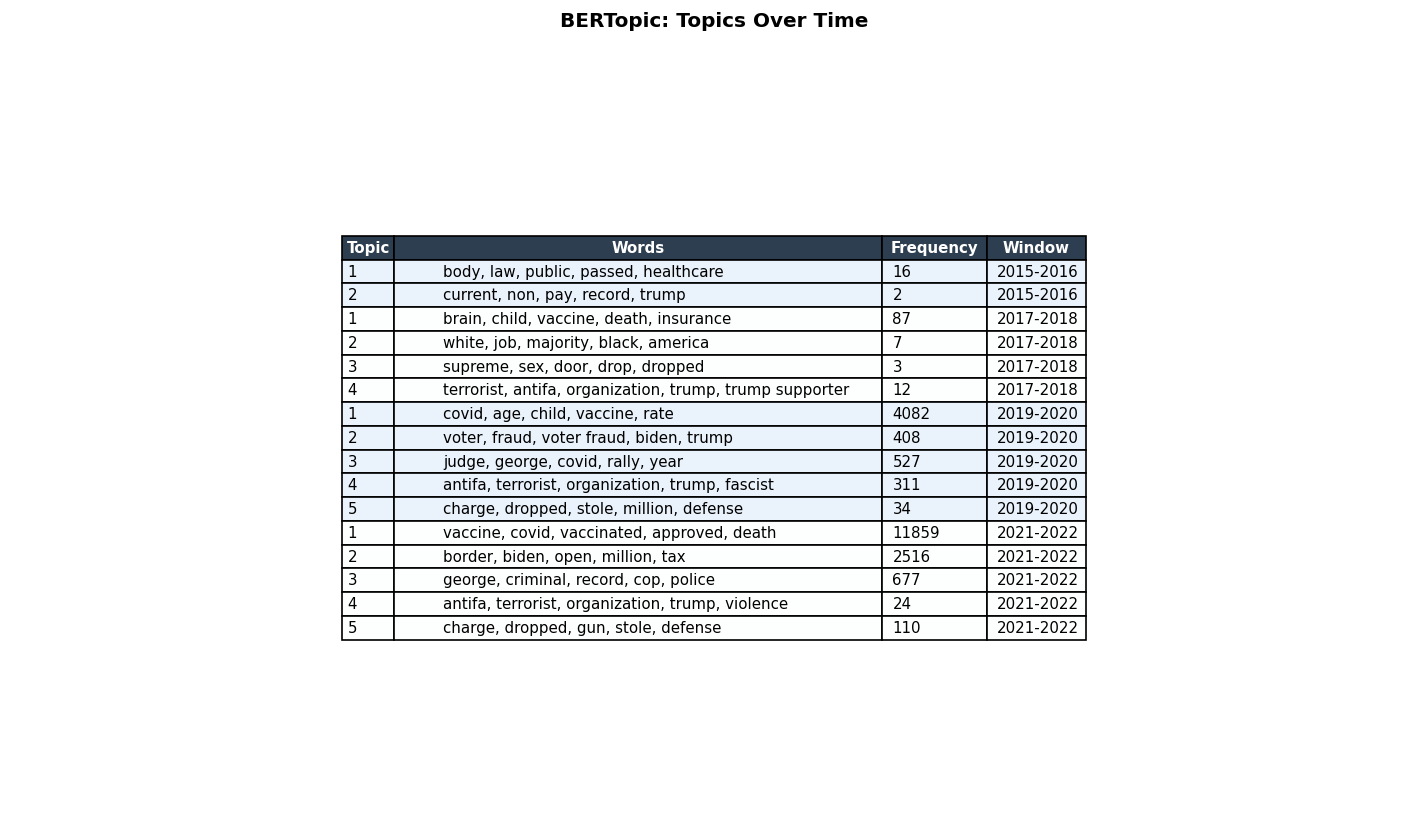

Saved → output//04_bertopic_topics_over_time.png


In [60]:
pivot_bt = bt_valid.pivot_table(index='Topic', columns='Timestamp',
                                values='Frequency', aggfunc='sum').fillna(0)

ordered_cols = [c for c in WINDOW_LABELS if c in pivot_bt.columns]
pivot_bt = pivot_bt[ordered_cols]
pivot_bt_norm = pivot_bt.div(pivot_bt.sum(axis=0), axis=1)

# Build display table — all windows including 2015-2016 for completeness
tot_out = bt_valid[['Topic', 'Words', 'Frequency', 'Timestamp']].copy()
tot_out = tot_out.sort_values(['Timestamp', 'Topic']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, len(tot_out) * 0.38 + 1))
ax.axis('off')

col_labels = ['Topic', 'Words', 'Frequency', 'Window']
cell_text = [
    [str(int(r.Topic)), r.Words, str(int(r.Frequency)), r.Timestamp]
    for r in tot_out.itertuples()
]

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='left',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width([0, 1, 2, 3])

# Header styling
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Alternating row shading per window
window_order = {w: i for i, w in enumerate(WINDOW_LABELS)}
for i, r in enumerate(tot_out.itertuples(), start=1):
    shade = '#eaf2fb' if window_order.get(r.Timestamp, 0) % 2 == 0 else '#fdfefe'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(shade)

plt.suptitle('BERTopic: Topics Over Time', fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_bertopic_topics_over_time.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {PLOT_DIR}/04_bertopic_topics_over_time.png")

## 7. Comparative Visualizations

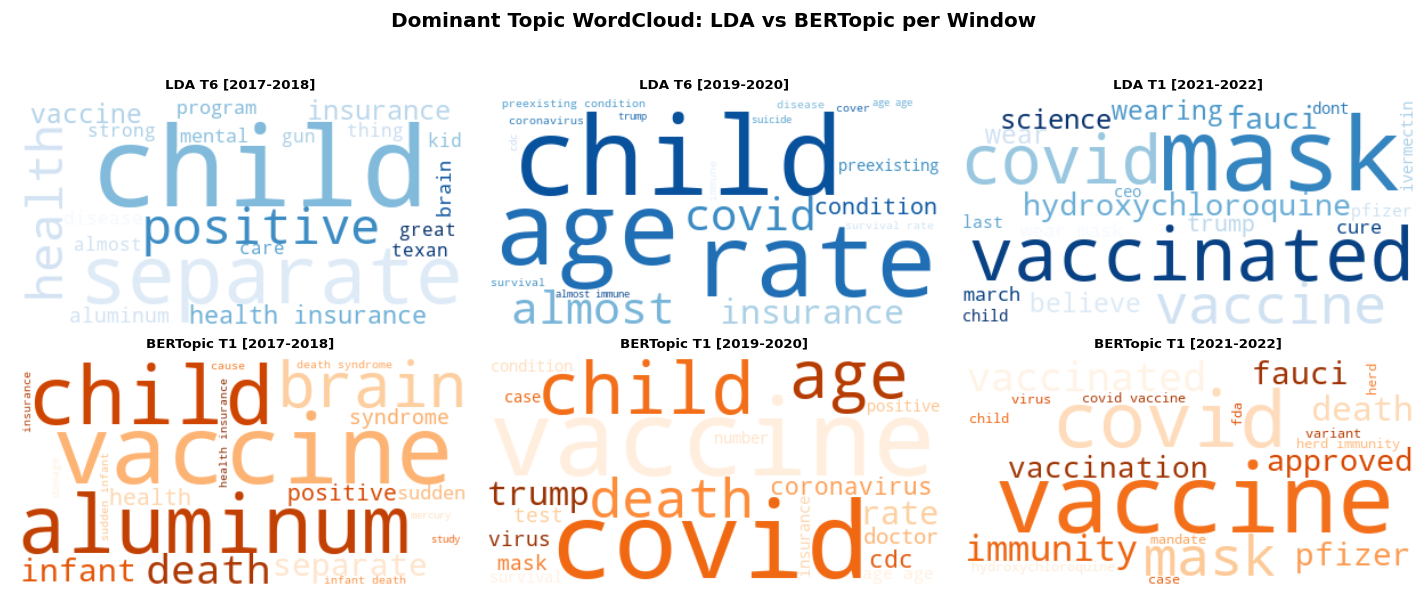

In [61]:
def generate_wordcloud(words, weights=None, title='', ax=None, colormap='Blues'):
    if weights is not None:
        freq_dict = dict(zip(words, weights))
    else:
        freq_dict = {w: 1 for w in words}
    wc = WordCloud(width=400, height=200, background_color='white',
                   colormap=colormap, max_words=50).generate_from_frequencies(freq_dict)
    if ax:
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title, fontsize=8, fontweight='bold')


def top_terms_from_docs(docs, max_terms=20):
    if len(docs) == 0:
        return [], []
    try:
        vec = CountVectorizer(stop_words='english', min_df=1, ngram_range=(1, 2))
        mat = vec.fit_transform(docs)
    except ValueError:
        return [], []
    scores = np.asarray(mat.sum(axis=0)).ravel()
    top_idx = scores.argsort()[::-1][:max_terms]
    vocab_local = vec.get_feature_names_out()
    return [vocab_local[i] for i in top_idx], scores[top_idx]


def lda_window_weighted_terms(win, dom_topic, max_terms=20):
    win_idx = temporal_reset.index[temporal_reset['time_window'] == win].to_numpy()
    if len(win_idx) == 0:
        return [], []
    topic_weights = doc_topic_global[win_idx, dom_topic]
    weighted_counts = np.asarray(dtm_global[win_idx].T.dot(topic_weights)).ravel()
    top_idx = weighted_counts.argsort()[::-1][:max_terms]
    return [vocab[i] for i in top_idx], weighted_counts[top_idx]


windows_lda_bt = [w for w in WINDOW_LABELS if w in lda_results]
n_windows = len(windows_lda_bt)

fig, axes = plt.subplots(2, n_windows, figsize=(4 * n_windows, 5))
if n_windows == 1:
    axes = axes.reshape(2, 1)

for j, win in enumerate(windows_lda_bt):
    # LDA dominant topic, visualised with window-level weighted word counts.
    mean_weights  = lda_results[win]['doc_topic_matrix'].mean(axis=0)
    dom_lda       = np.argmax(mean_weights)
    lda_words, lda_top_w = lda_window_weighted_terms(win, dom_lda, max_terms=20)
    generate_wordcloud(lda_words, lda_top_w,
                       title=f"LDA T{dom_lda+1} [{win}]",
                       ax=axes[0, j], colormap='Blues')

    # BERTopic dominant topic, visualised from docs in this window assigned to that topic.
    dom_bt    = bt_dom_per_window.get(win, 1)
    topic_ids = np.asarray(bt_topics)
    win_mask = (temporal_reset['time_window'] == win).to_numpy()
    bt_docs = temporal_reset.loc[win_mask & (topic_ids == dom_bt - 1), 'clean_text'].tolist()
    bt_words, bt_scores = top_terms_from_docs(bt_docs, max_terms=20)
    if len(bt_words) == 0:
        bt_row = bt_valid[(bt_valid['Timestamp'] == win) & (bt_valid['Topic'] == dom_bt)]
        bt_words = [w.strip() for w in bt_row.iloc[0]['Words'].split(',')] if len(bt_row) else []
        bt_scores = None
    generate_wordcloud(bt_words, bt_scores,
                       title=f"BERTopic T{dom_bt} [{win}]",
                       ax=axes[1, j], colormap='Oranges')

axes[0, 0].set_ylabel('LDA', fontsize=9)
axes[1, 0].set_ylabel('BERTopic', fontsize=9)
plt.suptitle('Dominant Topic WordCloud: LDA vs BERTopic per Window',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/05_dominant_topic_wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()

### 7b. Side-by-side top-terms comparison: LDA vs BERTopic (fake news only)

In [62]:
# Both models operate on temporal_df filtered to majority_target == 'False'
print("Side-by-side comparison: Dominant topic top terms per window (fake news only)")
print("=" * 80)
print(f"{'Window':<15} {'LDA Dominant Topic':<35} {'BERTopic Dominant Topic'}")
print("-" * 80)

for win in windows_lda_bt:
    mean_w    = lda_results[win]['doc_topic_matrix'].mean(axis=0)
    dom_lda   = np.argmax(mean_w)
    lda_words, _ = lda_window_weighted_terms(win, dom_lda, max_terms=6)
    lda_terms = ', '.join(lda_words)

    # Use window-level docs assigned to the dominant BERTopic topic.
    dom_bt   = bt_dom_per_window.get(win, 1)
    topic_ids = np.asarray(bt_topics)
    win_mask = (temporal_reset['time_window'] == win).to_numpy()
    bt_docs = temporal_reset.loc[win_mask & (topic_ids == dom_bt - 1), 'clean_text'].tolist()
    bt_words, _ = top_terms_from_docs(bt_docs, max_terms=6)
    if len(bt_words) == 0:
        bt_row = bt_valid[(bt_valid['Timestamp'] == win) & (bt_valid['Topic'] == dom_bt)]
        bt_words = [w.strip() for w in bt_row.iloc[0]['Words'].split(',')[:6]] if len(bt_row) else []
    bt_terms = ', '.join(bt_words)

    print(f"{win:<15} {lda_terms:<35} BERTopic T{dom_bt}: {bt_terms}")

Side-by-side comparison: Dominant topic top terms per window (fake news only)
Window          LDA Dominant Topic                  BERTopic Dominant Topic
--------------------------------------------------------------------------------
2017-2018       child, separate, positive, health, insurance, vaccine BERTopic T1: vaccine, aluminum, child, brain, death, separate
2019-2020       child, age, rate, almost, covid, insurance BERTopic T1: vaccine, covid, child, age, death, trump
2021-2022       mask, vaccinated, covid, vaccine, hydroxychloroquine, fauci BERTopic T1: vaccine, covid, mask, vaccinated, immunity, death


In [63]:
# Save 7b comparison as a copy-pastable table for the research paper
rows = []
for win in windows_lda_bt:
    mean_w    = lda_results[win]['doc_topic_matrix'].mean(axis=0)
    dom_lda   = np.argmax(mean_w)
    lda_words, _ = lda_window_weighted_terms(win, dom_lda, max_terms=6)
    lda_terms = ', '.join(lda_words)

    dom_bt   = bt_dom_per_window.get(win, 1)
    topic_ids_arr = np.asarray(bt_topics)
    win_mask = (temporal_reset['time_window'] == win).to_numpy()
    bt_docs = temporal_reset.loc[win_mask & (topic_ids_arr == dom_bt - 1), 'clean_text'].tolist()
    bt_words, _ = top_terms_from_docs(bt_docs, max_terms=6)
    if len(bt_words) == 0:
        bt_row = bt_valid[(bt_valid['Timestamp'] == win) & (bt_valid['Topic'] == dom_bt)]
        bt_words = [w.strip() for w in bt_row.iloc[0]['Words'].split(',')[:6]] if len(bt_row) else []
    bt_terms = ', '.join(bt_words)

    rows.append({
        'Time Window': win,
        'LDA Dominant Topic': f'Topic {dom_lda + 1}',
        'LDA Top Terms': lda_terms,
        'BERTopic Dominant Topic': f'Topic {dom_bt}',
        'BERTopic Top Terms': bt_terms,
    })

comparison_table = pd.DataFrame(rows)
comparison_table.to_csv(f"{PLOT_DIR}/06_lda_vs_bertopic_comparison.csv", index=False)
print(f"Saved -> {PLOT_DIR}/06_lda_vs_bertopic_comparison.csv")
print()
print(comparison_table.to_string(index=False))

Saved -> output//06_lda_vs_bertopic_comparison.csv

Time Window LDA Dominant Topic                                               LDA Top Terms BERTopic Dominant Topic                                BERTopic Top Terms
  2017-2018            Topic 6       child, separate, positive, health, insurance, vaccine                 Topic 1  vaccine, aluminum, child, brain, death, separate
  2019-2020            Topic 6                  child, age, rate, almost, covid, insurance                 Topic 1          vaccine, covid, child, age, death, trump
  2021-2022            Topic 1 mask, vaccinated, covid, vaccine, hydroxychloroquine, fauci                 Topic 1 vaccine, covid, mask, vaccinated, immunity, death


## 8. Topic Model Evaluation

Because LDA and BERTopic are unsupervised models, there is no ground-truth topic label to evaluate with accuracy. We therefore use two complementary checks: representative document inspection for semantic interpretability, and a chi-square test to assess whether dominant topic assignments vary across time windows.

In [ ]:
# 8a. Representative document inspection
#
# This checks whether each window's dominant topic is supported by tweets from
# that same window. This is more appropriate for dynamic topic modeling than
# selecting global representative docs, which over-represents 2021-2022.

N_REP_DOCS = 2

print("LDA window-level representative tweets")
print("=" * 80)

for win in windows_lda_bt:
    win_idx = temporal_reset.index[temporal_reset['time_window'] == win].to_numpy()
    mean_w = lda_results[win]['doc_topic_matrix'].mean(axis=0)
    dom_lda = int(np.argmax(mean_w))
    lda_words, _ = lda_window_weighted_terms(win, dom_lda, max_terms=10)
    doc_scores = doc_topic_global[win_idx, dom_lda]
    top_local_idx = np.argsort(doc_scores)[::-1][:N_REP_DOCS]
    print(f"\n[{win}] LDA Topic {dom_lda + 1}")
    print("Window-level top words:", ", ".join(lda_words))
    for rank, local_idx in enumerate(top_local_idx, start=1):
        idx = win_idx[local_idx]
        row = temporal_reset.iloc[idx]
        tweet = str(row['tweet']).replace("\n", " ")
        print(f"  {rank}. weight={doc_scores[local_idx]:.3f} | {tweet[:300]}")

print("\n\nBERTopic window-level representative tweets")
print("=" * 80)

bt_topics_arr = np.asarray(bt_topics)
for win in windows_lda_bt:
    dom_bt = int(bt_dom_per_window.get(win, 1))
    win_mask = (temporal_reset['time_window'] == win).to_numpy()
    doc_idx = np.where(win_mask & (bt_topics_arr == dom_bt - 1))[0]
    bt_words, _ = top_terms_from_docs(temporal_reset.iloc[doc_idx]['clean_text'].tolist(), max_terms=10)
    print(f"\n[{win}] BERTopic Topic {dom_bt}")
    print("Window-level top words:", ", ".join(bt_words))
    for rank, idx in enumerate(doc_idx[:N_REP_DOCS], start=1):
        row = temporal_reset.iloc[idx]
        tweet = str(row['tweet']).replace("\n", " ")
        print(f"  {rank}. {tweet[:300]}")

### 8b. Time Window × Dominant Topic Association

This test evaluates whether dominant topic assignments are independent of time windows. A significant chi-square result means topic prevalence changes over time. Cramér's V is included as an effect-size measure, since large datasets can make small differences statistically significant.

In [ ]:
# 8b. Chi-square test: time window × dominant topic

from scipy.stats import chi2_contingency

# LDA dominant topic per document
lda_dom_topics = np.argmax(doc_topic_global, axis=1) + 1
lda_eval = temporal_reset[['time_window']].copy()
lda_eval['DominantTopic'] = lda_dom_topics

lda_table = pd.crosstab(lda_eval['time_window'], lda_eval['DominantTopic'])
chi2, p, dof, expected = chi2_contingency(lda_table)
n = lda_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(lda_table.shape) - 1)))

print("LDA: time window × dominant topic")
print(lda_table)
print(f"\nchi-square={chi2:.2f}, dof={dof}, p-value={p:.3e}, Cramér's V={cramers_v:.3f}")

# BERTopic dominant topic per document; exclude outliers (-1)
bt_eval = temporal_reset[['time_window']].copy()
bt_eval['DominantTopic'] = np.asarray(bt_topics) + 1
bt_eval = bt_eval[bt_eval['DominantTopic'] != 0].copy()

bt_table = pd.crosstab(bt_eval['time_window'], bt_eval['DominantTopic'])
chi2_bt, p_bt, dof_bt, expected_bt = chi2_contingency(bt_table)
n_bt = bt_table.to_numpy().sum()
cramers_v_bt = np.sqrt(chi2_bt / (n_bt * (min(bt_table.shape) - 1)))

print("\n\nBERTopic: time window × dominant topic")
print(bt_table)
print(f"\nchi-square={chi2_bt:.2f}, dof={dof_bt}, p-value={p_bt:.3e}, Cramér's V={cramers_v_bt:.3f}")